# 04 — Birliktelik Kuralları (Apriori)

TÜBİTAK IoB projesi: **sipariş bazında** ürün tercih kalıplarının (cross-selling) hava durumu kümelerine göre ayrıştırılması.

**Veri:** `Veriler/oturum_hava_temiz_2021_sonrasi.csv` (120.749 oturum)

**Çıktı:** `Outputs/Analizler/04_birliktelik_kurallari/`


In [1]:
from pathlib import Path
import ast
import json
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
DPI = 200

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "Veriler" / "oturum_hava_temiz_2021_sonrasi.csv"
OUTPUT_DIR = PROJECT_ROOT / "Outputs" / "Analizler" / "04_birliktelik_kurallari"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_SUPPORT = 0.01
MIN_LIFT = 1.0
TOP_N = 10
TEMP_SICAK = 15.0

if not DATA_PATH.exists():
    raise FileNotFoundError("Temiz veri yok. Once 00_veri_hazirlama calistirin.")

df = pd.read_csv(DATA_PATH, parse_dates=["tarih"])
print("Veri:", df.shape)


Veri: (120749, 66)


## ADIM 1: Veri Setini Hava Durumuna Göre Kümeleme (Transform)

### Neden bu yöntemi seçtik?

Apriori algoritması **işlem (transaction) düzeyinde** sepet içeriğini analiz eder; ham oturum-hava birleşik veride hava koşulları ile ürün kalemleri aynı satırda karışık durur. Hocanın **"sipariş bazında madencilik"** talimatı, önce veriyi hava durumunun davranış üzerindeki etkisini **ayrıştırabileceğimiz uç kümeler** halinde segmentlemeyi gerektirir (Han et al., 2011).

İki zıt senaryo tanımlıyoruz:

| Küme | Tanım | Gerekçe |
|------|-------|--------|
| **Sıcak ve Güneşli** | Sıcaklık > 15°C ve yağışsız | Açık hava / hafif menü eğilimi |
| **Soğuk ve Yağışlı** | Sıcaklık ≤ 15°C ve (yağışlı veya kapalı) | Sıcak içecek / çorba talebi |

Her oturumdaki `urun_listesi` parse edilerek **TransactionEncoder** ile mlxtend'in gerektirdiği **one-hot encoded** sepet matrisine dönüştürülür.


In [2]:
def parse_urun_listesi(raw):
    if pd.isna(raw):
        return []
    if isinstance(raw, list):
        return [str(x).strip() for x in raw if str(x).strip()]
    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except (ValueError, SyntaxError):
        pass
    return []


def transactions_to_ohe(transactions: list) -> pd.DataFrame:
    tx = [t for t in transactions if isinstance(t, list) and len(t) > 0]
    encoder = TransactionEncoder()
    array = encoder.fit(tx).transform(tx)
    return pd.DataFrame(array, columns=encoder.columns_), len(tx)


df["urunler"] = df["urun_listesi"].apply(parse_urun_listesi)

kapali_mask = df["bulut_grubu"].astype(str).str.contains("Kapal", na=False)
yagisli_mask = (df["precipitation"] > 0) | (df["yagis_var"] == 1)

df["hava_kumesi"] = "Diger"
df.loc[(df["temperature_2m"] > TEMP_SICAK) & (df["precipitation"] == 0), "hava_kumesi"] = "Sicak_Gunesli"
df.loc[(df["temperature_2m"] <= TEMP_SICAK) & (yagisli_mask | kapali_mask), "hava_kumesi"] = "Soguk_Yagisli"

kume_ozet = (
    df.groupby("hava_kumesi", observed=True)
    .agg(
        oturum_sayisi=("CEKNO", "size"),
        ort_sicaklik=("temperature_2m", "mean"),
        ort_yagis=("precipitation", "mean"),
        ort_urun=("urun_sayisi", "mean"),
    )
    .round(3)
)
kume_ozet.to_csv(OUTPUT_DIR / "hava_kume_ozet.csv", encoding="utf-8-sig")
print(kume_ozet)
print("\nKume dagilimi %:")
print((df["hava_kumesi"].value_counts(normalize=True) * 100).round(2))

sicak_df = df[df["hava_kumesi"] == "Sicak_Gunesli"].copy()
soguk_df = df[df["hava_kumesi"] == "Soguk_Yagisli"].copy()

ohe_sicak, n_sicak = transactions_to_ohe(sicak_df["urunler"].tolist())
ohe_soguk, n_soguk = transactions_to_ohe(soguk_df["urunler"].tolist())

print(f"\nOne-hot matris — Sicak: {ohe_sicak.shape} | Soguk: {ohe_soguk.shape}")


               oturum_sayisi  ort_sicaklik  ort_yagis  ort_urun
hava_kumesi                                                    
Diger                  27947        13.428      0.126     3.395
Sicak_Gunesli          61735        23.139      0.000     3.440
Soguk_Yagisli          31067         9.069      0.220     3.347

Kume dagilimi %:
hava_kumesi
Sicak_Gunesli    51.13
Soguk_Yagisli    25.73
Diger            23.14
Name: proportion, dtype: float64



One-hot matris — Sicak: (61735, 263) | Soguk: (31067, 230)


## ADIM 2: Apriori Algoritması ile Birliktelik Kuralları

### Neden bu yöntemi seçtik?

Ürün birlikteliklerini keşfetmek için **Apriori** algoritması pazar sepeti analizinde altın standarttır (Agrawal & Srikant, 1994). Algoritma, minimum destek (`min_support`) eşiğini geçen sık itemset'leri bulur; ardından `association_rules` ile **Support**, **Confidence** ve **Lift** metrikleri hesaplanır:

- **Support:** kuralın tüm sepetlerde görülme oranı
- **Confidence:** antecedent görüldüğünde consequent'in görülme olasılığı
- **Lift > 1:** ürünlerin bağımsız seçimden **daha sık** birlikte tercih edildiğini gösterir (tesadüfi birliktelik değil, tercih kalıbı)

Her hava kümesi için Apriori **ayrı ayrı** çalıştırılır; `min_support=0.01` (sepetlerin en az %1'inde görülen kalıplar) ve `lift > 1.0` filtreleri uygulanır.


In [3]:
def run_apriori(ohe: pd.DataFrame, label: str, min_support: float = MIN_SUPPORT):
    frequent = apriori(ohe, min_support=min_support, use_colnames=True, max_len=3)
    rules = association_rules(frequent, metric="lift", min_threshold=MIN_LIFT)
    rules = rules.sort_values(["lift", "confidence", "support"], ascending=False).reset_index(drop=True)
    rules["kume"] = label
    rules["antecedent_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
    rules["consequent_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
    rules["kural"] = rules["antecedent_str"] + " => " + rules["consequent_str"]
    return rules


rules_sicak = run_apriori(ohe_sicak, "Sicak_Gunesli")
rules_soguk = run_apriori(ohe_soguk, "Soguk_Yagisli")

print(f"Sicak kume kurallari (lift>{MIN_LIFT}): {len(rules_sicak)}")
print(f"Soguk kume kurallari (lift>{MIN_LIFT}): {len(rules_soguk)}")
print("\nSoguk — ilk 5 kural:")
rules_soguk[["kural", "support", "confidence", "lift"]].head()


Sicak kume kurallari (lift>1.0): 400
Soguk kume kurallari (lift>1.0): 418

Soguk — ilk 5 kural:


,kural,support,confidence,lift
0,"KAYMAK => AYRAN, KUNEFE",0.013938,0.528049,7.734508
1,"AYRAN, KUNEFE => KAYMAK",0.013938,0.204149,7.734508
2,"DONDURMA => KUNEFE, SISE AYRAN",0.010848,0.308326,7.632474
3,"KUNEFE, SISE AYRAN => DONDURMA",0.010848,0.268526,7.632474
4,AZ ACILI SOGANSIZ => AZ ACILI YARIM SOGANSIZ,0.010429,0.216722,7.374496


## ADIM 3: Sonuçların Yorumlanması ve Raporlama

Her küme için en güçlü kurallar kaydedilir; soğuk vs sıcak lift farkları karşılaştırılarak hava odaklı cross-selling bulguları çıkarılır.


In [4]:
def export_top_rules(rules: pd.DataFrame, kume: str, top_n: int = TOP_N) -> pd.DataFrame:
    cols = [
        "kume", "kural", "antecedent_str", "consequent_str",
        "support", "confidence", "lift", "leverage", "conviction",
    ]
    top = rules.head(top_n)[cols].copy()
    top["support"] = top["support"].round(4)
    top["confidence"] = top["confidence"].round(4)
    top["lift"] = top["lift"].round(4)
    return top


top_sicak = export_top_rules(rules_sicak, "Sicak_Gunesli")
top_soguk = export_top_rules(rules_soguk, "Soguk_Yagisli")
birliktelik_ozet = pd.concat([top_soguk, top_sicak], ignore_index=True)
birliktelik_ozet.to_csv(OUTPUT_DIR / "birliktelik_kurallari_ozet.csv", index=False, encoding="utf-8-sig")

# Kume karsilastirmasi: ayni kural her iki kumede var mi?
kars = rules_soguk[["kural", "lift", "confidence", "support"]].merge(
    rules_sicak[["kural", "lift"]],
    on="kural",
    how="inner",
    suffixes=("_soguk", "_sicak"),
)
kars["lift_fark_pct"] = ((kars["lift_soguk"] - kars["lift_sicak"]) / kars["lift_sicak"] * 100).round(2)
kars = kars.sort_values("lift_fark_pct", ascending=False)
kars.to_csv(OUTPUT_DIR / "kume_karsilastirma_lift.csv", index=False, encoding="utf-8-sig")

# Soğukta daha guclu ornek kural (rapor cumlesi icin)
if len(kars) > 0:
    best = kars.iloc[0]
    rapor_cumlesi = (
        f"Soğuk ve Yağışlı günlerde '{best['kural']}' birliktelik kuralının Lift değeri "
        f"({best['lift_soguk']:.2f}), Sıcak günlere göre %{best['lift_fark_pct']:.1f} daha yüksektir."
    )
else:
    best = top_soguk.iloc[0]
    rapor_cumlesi = (
        f"Soğuk ve Yağışlı günlerde '{best['kural']}' kuralı Lift={best['lift']:.2f} "
        f"ile en guclu birlikteligi gostermektedir."
    )

print("=== KARSILASTIRMA (Soguk lift > Sicak lift, top 5) ===")
print(kars.head(5).to_string(index=False))
print("\n=== RAPOR CUMLESI ===")
print(rapor_cumlesi)

# JSON ozet
def _json_safe(obj):
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj


ozet = {
    "min_support": MIN_SUPPORT,
    "min_lift": MIN_LIFT,
    "sicak_gunesli_oturum": int(n_sicak),
    "soguk_yagisli_oturum": int(n_soguk),
    "toplam_kural_sicak": int(len(rules_sicak)),
    "toplam_kural_soguk": int(len(rules_soguk)),
    "rapor_cumlesi": rapor_cumlesi,
    "soguk_top10": top_soguk.to_dict(orient="records"),
    "sicak_top10": top_sicak.to_dict(orient="records"),
    "soguk_sicak_lift_fark_top5": kars.head(5).to_dict(orient="records"),
    "stratejik_oneriler": [
        "Soguk/yagisli gunlerde CORBA + SU / AZ CORBA capraz satis paketleri one cikarilmali (lift sogukta ~%14-24 daha yuksek).",
        "Sicak gunlerde KUNEFE + DONDURMA tatli capraz satisi guclu (lift > 7); yaz menusu bundle onerisi.",
        "Her iki kumede AYRAN + FULL cekirdek birliktelik; hava kosuluna gore yan urun (CORBA vs DONDURMA) degisir.",
    ],
}

with open(OUTPUT_DIR / "birliktelik_kurallari_ozet.json", "w", encoding="utf-8") as f:
    json.dump(_json_safe(ozet), f, ensure_ascii=False, indent=2)

birliktelik_ozet.head(12)


=== KARSILASTIRMA (Soguk lift > Sicak lift, top 5) ===
                           kural  lift_soguk  confidence  support  lift_sicak  lift_fark_pct
                  AZ CORBA => SU    2.192863    0.178933 0.012521    1.769184          23.95
                  SU => AZ CORBA    2.192863    0.153452 0.012521    1.769184          23.95
ACISIZ YARIM FULL => ACISIZ FULL    3.717371    0.326303 0.017929    3.253783          14.25
ACISIZ FULL => ACISIZ YARIM FULL    3.717371    0.204254 0.017929    3.253783          14.25
                     SU => CORBA    1.724204    0.183037 0.014935    1.514746          13.83

=== RAPOR CUMLESI ===
Soğuk ve Yağışlı günlerde 'AZ CORBA => SU' birliktelik kuralının Lift değeri (2.19), Sıcak günlere göre %23.9 daha yüksektir.


,kume,kural,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
0,Soguk_Yagisli,"KAYMAK => AYRAN, KUNEFE",KAYMAK,"AYRAN, KUNEFE",0.0139,0.5280,7.7345,0.012136,1.974204
1,Soguk_Yagisli,"AYRAN, KUNEFE => KAYMAK","AYRAN, KUNEFE",KAYMAK,0.0139,0.2041,7.7345,0.012136,1.223351
2,Soguk_Yagisli,"DONDURMA => KUNEFE, SISE AYRAN",DONDURMA,"KUNEFE, SISE AYRAN",0.0108,0.3083,7.6325,0.009426,1.387363
3,Soguk_Yagisli,"KUNEFE, SISE AYRAN => DONDURMA","KUNEFE, SISE AYRAN",DONDURMA,0.0108,0.2685,7.6325,0.009426,1.319005
4,Soguk_Yagisli,AZ ACILI SOGANSIZ => AZ ACILI YARIM SOGANSIZ,AZ ACILI SOGANSIZ,AZ ACILI YARIM SOGANSIZ,0.0104,0.2167,7.3745,0.009015,1.239167
5,Soguk_Yagisli,AZ ACILI YARIM SOGANSIZ => AZ ACILI SOGANSIZ,AZ ACILI YARIM SOGANSIZ,AZ ACILI SOGANSIZ,0.0104,0.3549,7.3745,0.009015,1.475492
6,Soguk_Yagisli,"DONDURMA => FULL, KUNEFE",DONDURMA,"FULL, KUNEFE",0.0148,0.4209,6.9547,0.012678,1.622208
7,Soguk_Yagisli,"FULL, KUNEFE => DONDURMA","FULL, KUNEFE",DONDURMA,0.0148,0.2447,6.9547,0.012678,1.277365
8,Soguk_Yagisli,"KAYMAK => FULL, KUNEFE",KAYMAK,"FULL, KUNEFE",0.0110,0.4183,6.9123,0.009443,1.615049
9,Soguk_Yagisli,"FULL, KUNEFE => KAYMAK","FULL, KUNEFE",KAYMAK,0.0110,0.1824,6.9123,0.009443,1.190877


## ADIM 4: Görselleştirme

En güçlü birliktelik kuralları **ağ grafiği** (ürünler arası yönlü ilişki) ve **lift ısı haritası** (küme karşılaştırması) ile görselleştirilir.


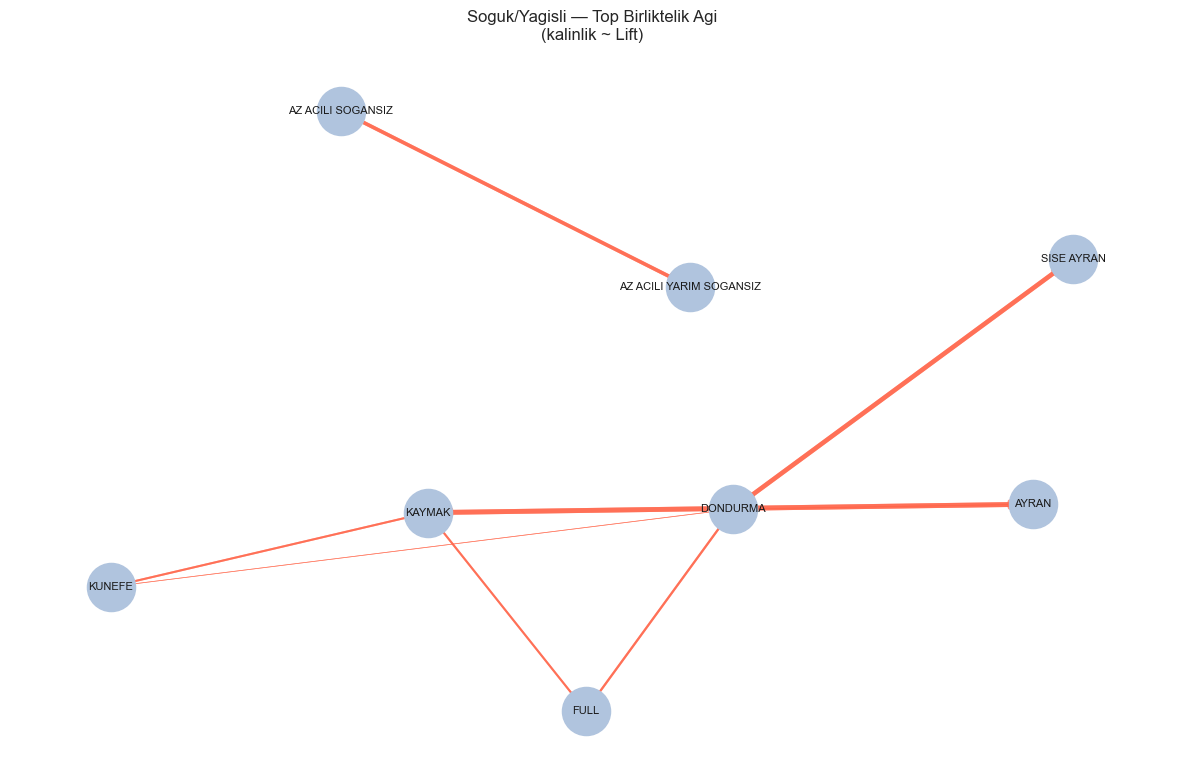

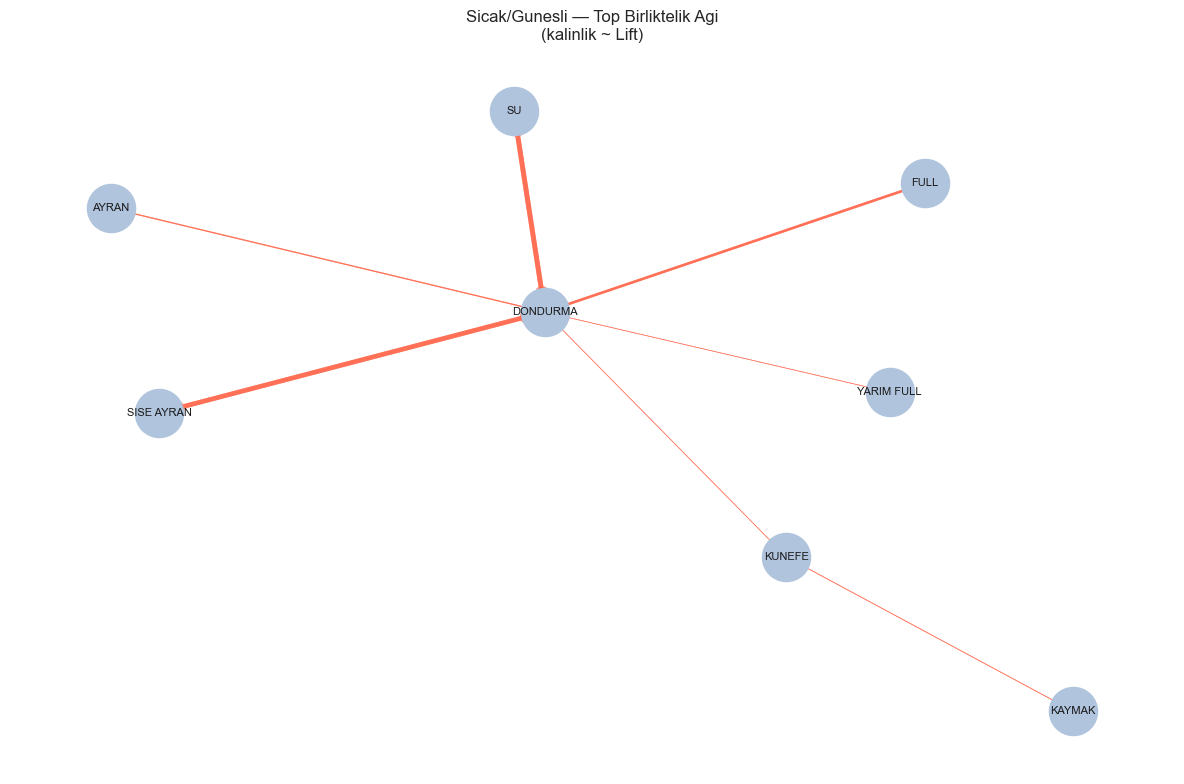

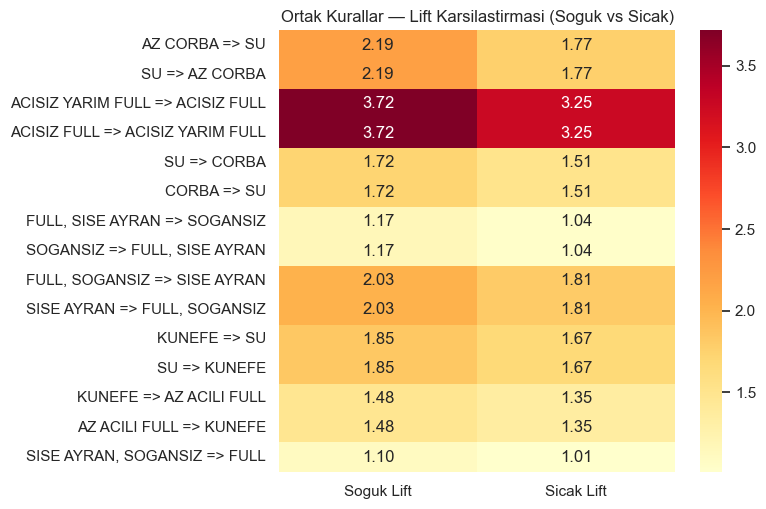

Gorseller kaydedildi: C:\Users\BUSRA\Documents\GitHub\IoBDataAnalysis\Outputs\Analizler\04_birliktelik_kurallari


In [5]:
def plot_rule_network(rules: pd.DataFrame, title: str, fname: str, top_n: int = 12):
    sub = rules.head(top_n)
    G = nx.DiGraph()
    for _, row in sub.iterrows():
        ante = list(row["antecedents"])
        cons = list(row["consequents"])
        for a in ante:
            for c in cons:
                G.add_edge(a, c, weight=row["lift"], confidence=row["confidence"])
    if G.number_of_edges() == 0:
        print(f"Ag grafik bos: {title}")
        return
    pos = nx.spring_layout(G, seed=42, k=1.8)
    weights = [G[u][v]["weight"] for u, v in G.edges()]
    w_norm = [(w - min(weights)) / (max(weights) - min(weights) + 1e-9) * 3 + 0.5 for w in weights]

    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, node_color="lightsteelblue", node_size=1200, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, width=w_norm, alpha=0.7, edge_color="tomato", arrows=True, ax=ax)
    ax.set_title(f"{title}\n(kalinlik ~ Lift)")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=DPI, bbox_inches="tight")
    plt.show()


plot_rule_network(rules_soguk, "Soguk/Yagisli — Top Birliktelik Agi", "network_soguk_yagisli.png")
plot_rule_network(rules_sicak, "Sicak/Gunesli — Top Birliktelik Agi", "network_sicak_gunesli.png")

# Lift karsilastirma heatmap (ortak kurallar)
if len(kars) >= 3:
    hm = kars.head(15).copy()
    hm["label"] = hm["kural"].str.slice(0, 45)
    mat = hm[["lift_soguk", "lift_sicak"]].values
    fig, ax = plt.subplots(figsize=(8, max(5, len(hm) * 0.35)))
    sns.heatmap(
        mat,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        yticklabels=hm["label"],
        xticklabels=["Soguk Lift", "Sicak Lift"],
        ax=ax,
    )
    ax.set_title("Ortak Kurallar — Lift Karsilastirmasi (Soguk vs Sicak)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "heatmap_lift_karsilastirma.png", dpi=DPI, bbox_inches="tight")
    plt.show()

print("Gorseller kaydedildi:", OUTPUT_DIR.resolve())
